In [1]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

df1 = pd.read_csv("pairing_results_round2_data1.csv")
df2 = pd.read_csv("pairing_results_round2_data2.csv")
df3 = pd.read_csv("pairing_results_round2_data3.csv")
df4 = pd.read_csv("pairing_results_round2_data4.csv")
df5 = pd.read_csv("pairing_results_round2_data5.csv")
df6 = pd.read_csv("pairing_results_round2_data6.csv")

column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv("heatflux_all_round2_data1.csv",header=None, names=column_names)
hf2 = pd.read_csv("heatflux_all_round2_data2.csv",header=None, names=column_names)
hf3 = pd.read_csv("heatflux_all_round2_data3.csv",header=None, names=column_names)
hf4 = pd.read_csv("heatflux_all_round2_data4.csv",header=None, names=column_names)
hf5 = pd.read_csv("heatflux_all_round2_data5.csv",header=None, names=column_names)
hf6 = pd.read_csv("heatflux_all_round2_data6.csv",header=None, names=column_names)



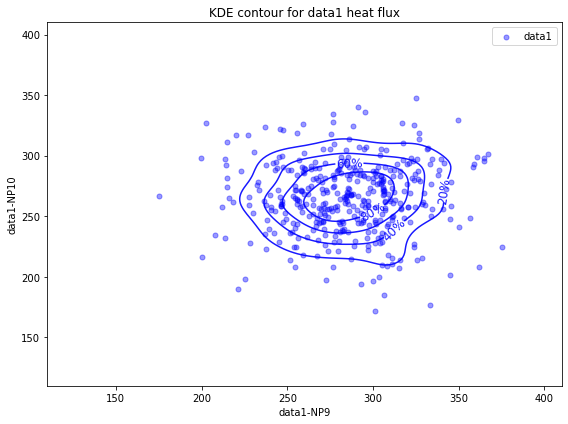

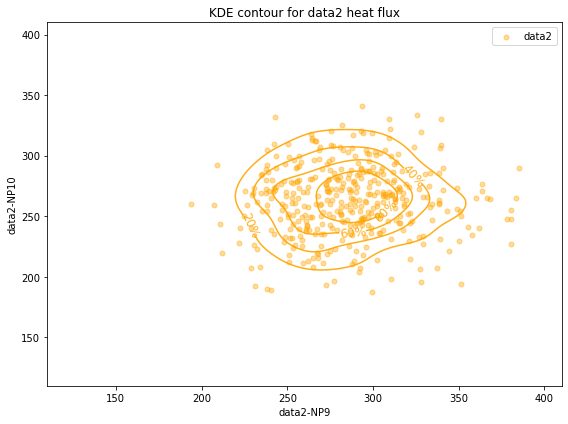

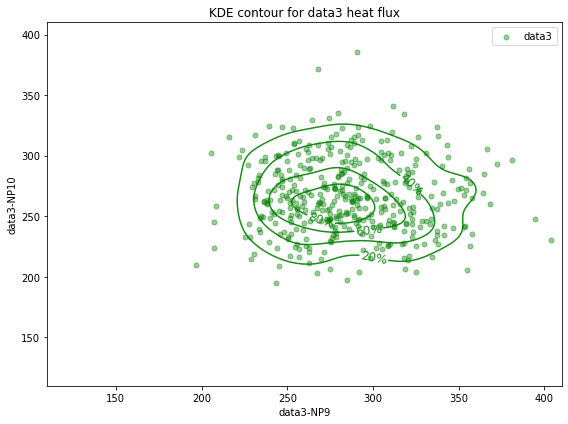

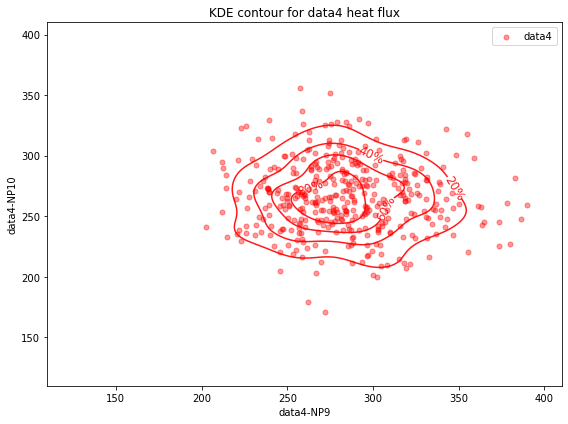

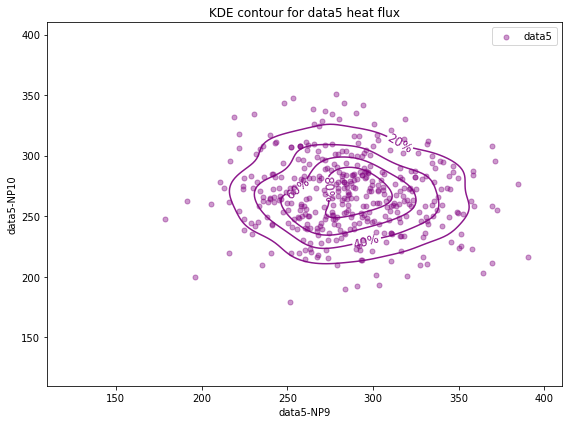

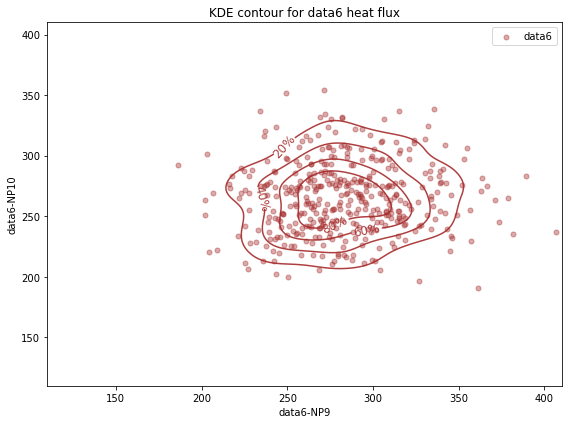

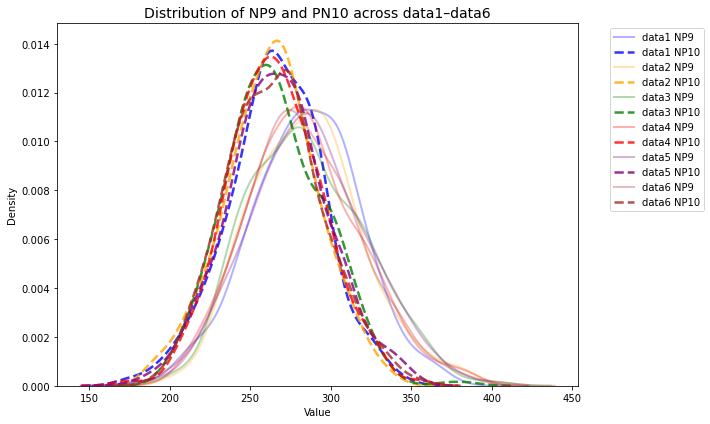

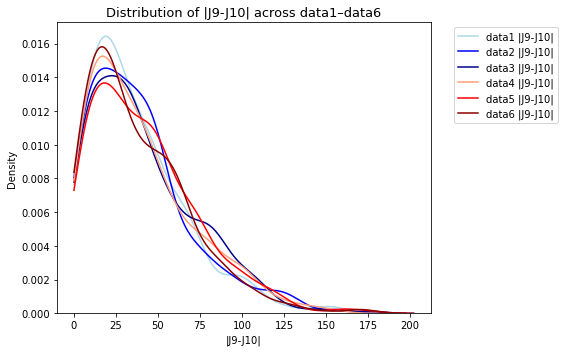

     pairing_num        col1        col2        col3        col4        col5  \
6              7   60.122921   22.611222   35.281692    4.434611    6.176609   
20            21   49.545167   58.351447   64.599164   13.411179   13.384825   
23            24  129.413855  157.043359  131.484140   22.791117   52.232952   
27            28   53.617189   66.967948   29.361631  119.963251  100.260072   
38            39    4.598278   16.967602    5.755182   38.183238   72.669135   
88            89   12.364060   11.425626    5.826165   67.943874   50.080286   
114          115   99.111191   79.399624   68.734914    2.784852    3.469398   
137          138   33.669075   31.163583   78.760508   20.909086    2.036132   
142          143   35.341121   47.777515   83.286931    6.921562   19.756747   
151          152    0.399471    9.495183    3.711371   20.167779   16.725677   
152          153   20.113184   33.139935   17.048824    8.592558   16.019470   
156          157   67.328165   47.322589

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = [hf1, hf2, hf3, hf4, hf5, hf6]

labels = [f"data{i}" for i in range(1, 7)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

for df, label, base_color in zip(datasets, labels, base_colors):
    plt.figure(figsize=(8, 6))
    x = df.iloc[:, 8].values
    y = df.iloc[:, 9].values

    # Scatter points
    plt.scatter(x, y, s=25, alpha=0.4, color=base_color, label=f'{label}')

    # --- Compute KDE manually so we can label contours ---
    kde = gaussian_kde(np.vstack([x, y]))
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # Create grid
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled = Z / Z.max() * 100  # 0–100%
    CS = plt.contour(X, Y, Z_scaled, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    plt.clabel(CS, inline=True, fontsize=12, fmt='%.0f%%')  # shows % of max density
    # --- Draw and label contours ---
    #CS = plt.contour(X, Y, Z, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    #plt.clabel(CS, inline=True, fontsize=8, fmt='%1.3f')  # Label with density values

    plt.xlabel(f'{label}-NP9')
    plt.ylabel(f'{label}-NP10')
    plt.xlim((110,410))
    plt.ylim((110,410))
    plt.legend()
    plt.title(f'KDE contour for {label} heat flux')
    plt.tight_layout()
    plt.show()



plt.figure(figsize=(10, 6))

for df, label, base_color in zip(datasets, labels, base_colors):
    # lighter shade for column 9
    sns.kdeplot(df.iloc[:, 8],clip=(0, None), label=f'{label} NP9', color=base_color, alpha=0.3, linewidth=2)
    # darker shade for column 10
    sns.kdeplot(df.iloc[:, 9], label=f'{label} NP10', color=base_color, alpha=0.8, linewidth=2.5, linestyle='--')

plt.title('Distribution of NP9 and PN10 across data1–data6', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Compute the sum of column 9 and 10 for each dataframe
# (Python is 0-indexed, so column 9 → index 8, column 10 → index 9)
output = pd.DataFrame({
    f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)
    for i, df in enumerate(datasets)
})

base_colors2 = ['#ADD8E6','#0000FF',  '#00008B',  # blue, light blue, dark blue
                '#FFA07A', '#FF0000', '#8B0000']  # red, light red, dark red
# Plot KDE distributions for all (J9-J10)^2
plt.figure(figsize=(8, 5))
for i, (label, base_color) in enumerate(zip(labels, base_colors2)):
    sns.kdeplot(output[f"col{i+1}"],clip=(0, None), label=f'{label} |J9-J10|', color=base_color, fill=False)

plt.title('Distribution of |J9-J10| across data1–data6', fontsize=13)
plt.xlabel('|J9-J10|')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Compare first 3 columns (0,1,2) with next 3 columns (3,4,5)
left = output.iloc[:, 0:3]
right = output.iloc[:, 3:6]

# Condition: every element in left < every element in right for that row
condition = ((left.max(axis=1) < right.min(axis=1))|(left.min(axis=1) > right.max(axis=1)))
#condition = (left.min(axis=1) > right.max(axis=1))

# Rows that satisfy the condition
filtered_output = output[condition]
filtered_pairs = df1[condition]

filtered_output.insert(0, filtered_pairs.columns[0], filtered_pairs.iloc[:, 0])

print(filtered_output)

# Save to CSV if desired
output.to_csv("sum_output_data1-6.csv", index=False)

/var/folders/h0/fh3ps4592l92zlj4lhkwz7x40000gn/T/ipykernel_8781/2348892432.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_output["min_diff"] = min_diffs


     row ID  pairing_num        col1        col2        col3        col4  \
302     302          303   20.790251   13.626067   21.859238   11.704757   
248     248          249   38.677169   25.646145  111.613328   20.079270   
152     152          153   20.113184   33.139935   17.048824    8.592558   
267     267          268   17.625547    4.314065    1.535685   18.696077   
316     316          317   21.451951    0.811106   29.060444   39.378889   
195     195          196    1.861696   20.719460   16.210729   22.138430   
379     379          380    6.229165   23.233486    7.481587   33.619832   
38       38           39    4.598278   16.967602    5.755182   38.183238   
266     266          267   24.006024   29.327117   55.896049   10.909399   
247     247          248   39.586128   45.875554   40.880713    7.676268   
356     356          357    8.706123   20.451383    5.077713   24.763270   
359     359          360   37.193624    0.713416   37.600823   90.962039   
175     175 

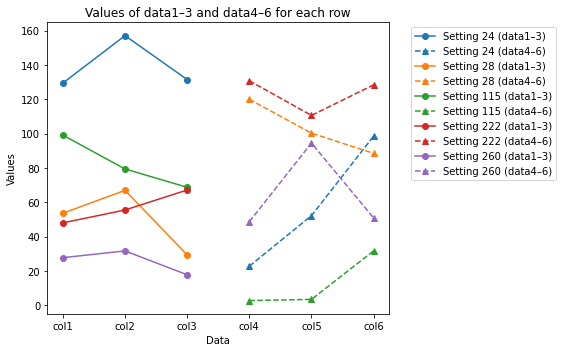

In [3]:
import numpy as np
import pandas as pd

# Example: data1 = pd.read_csv("data1.csv")

# Extract the two groups of columns
group1 = filtered_output.iloc[:, [1, 2, 3]].values  # col1–3
group2 = filtered_output.iloc[:, [4, 5, 6]].values  # col4–6

# Compute the minimum absolute difference row by row
min_diffs = [np.min(np.abs(g2[:, None] - g1)) for g1, g2 in zip(group1, group2)]

# Add result as a new column
filtered_output["min_diff"] = min_diffs
filtered_output_sorted = filtered_output.sort_values(by="min_diff", ascending=True)

filtered_output_sorted.insert(0, "row ID", filtered_output_sorted.index)
print(filtered_output_sorted)
#filtered_output_sorted.to_csv("filtered_output_sorted_redo.csv", index=False)

print(" | ".join(["row ID"] + list(df1.columns)))
id1 = filtered_output_sorted.index[-1]
print([id1] + list(df1.loc[id1, :]))
id2 = filtered_output_sorted.index[-2]
print([id2] + list(df1.loc[id2, :]))
id3 = filtered_output_sorted.index[-3]
print([id3] + list(df1.loc[id3, :]))
id4 = filtered_output_sorted.index[-4]
print([id4] + list(df1.loc[id4, :]))
id5 = filtered_output_sorted.index[-5]
print([id5] + list(df1.loc[id5, :]))

# Collect the top 5 row IDs
ids = filtered_output_sorted.index[-5:]  # last 5 rows in the sorted index
filtered_output_sorted_best5 = filtered_output_sorted.loc[ids, :].copy()
filtered_output_sorted_best5 = filtered_output_sorted_best5.sort_values(by="pairing_num", ascending=True)

# Extract the rows from df1
best5 = df1.loc[ids, :].copy()

# Optionally, add the row ID as a column
#best5.insert(0, "row ID", best5.index)

# Save to CSV
best5.to_csv("best5output_redo.csv", index=False)

filtered_output_sorted_best5["pairing_num"] = filtered_output_sorted_best5["pairing_num"].astype(int)

# Select column groups
cols1 = ["col1", "col2", "col3"]
cols2 = ["col4", "col5", "col6"]

colors = plt.cm.tab10.colors  

plt.figure(figsize=(8, 5))

for i, (idx, row) in enumerate(filtered_output_sorted_best5.iterrows()):
    color = colors[i % len(colors)]

    # Plot col1–3 with circles
    plt.plot(cols1, row[cols1], marker='o', linestyle='-', color=color,label=f'Setting {row["pairing_num"].astype(int)} (data1–3)')
    
    # Plot col4–6 with triangles
    plt.plot(cols2, row[cols2], marker='^', linestyle='--', color=color,label=f'Setting {row["pairing_num"].astype(int)} (data4–6)')

plt.title('Values of data1–3 and data4–6 for each row')
plt.xlabel('Data')
plt.ylabel('Values')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plot_best5output.pdf")   # saves current figure as PDF
plt.show()



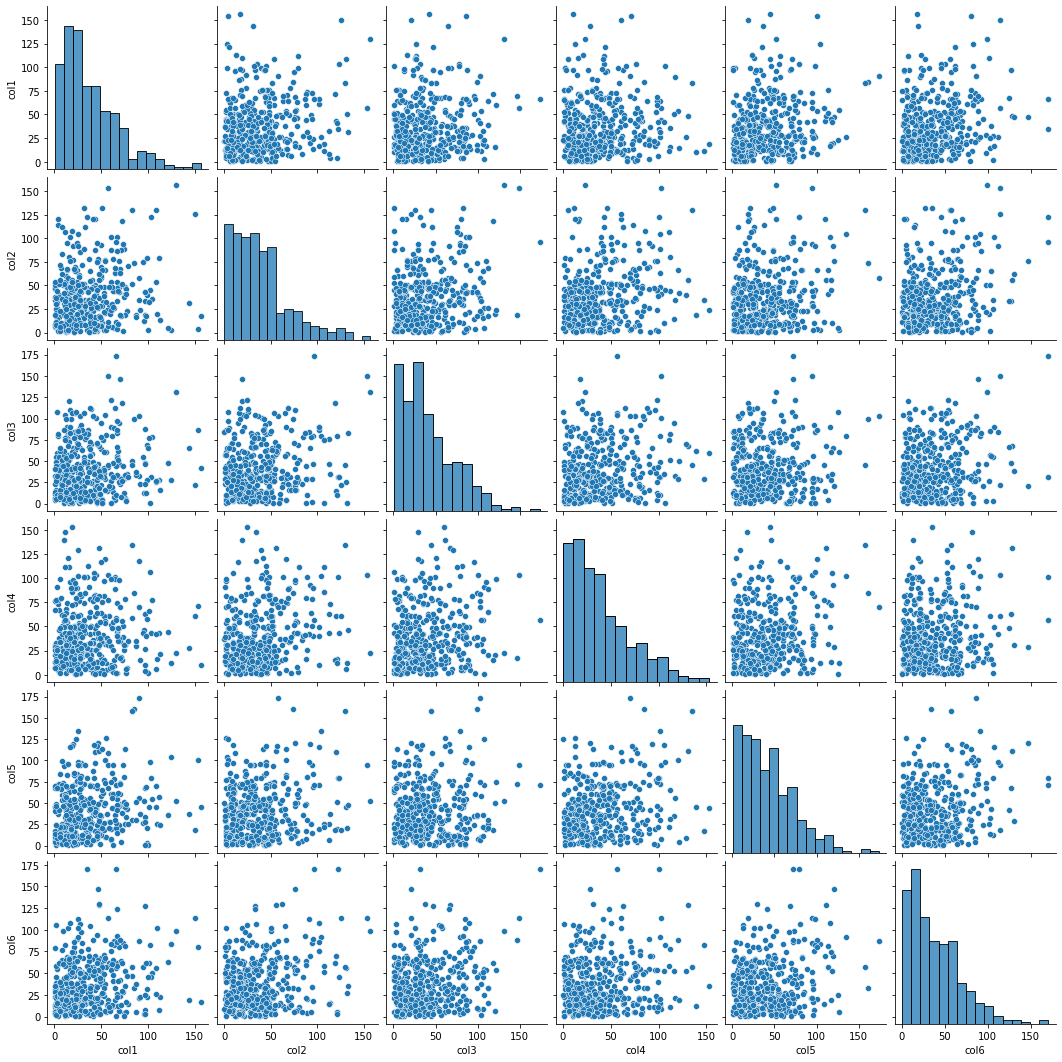

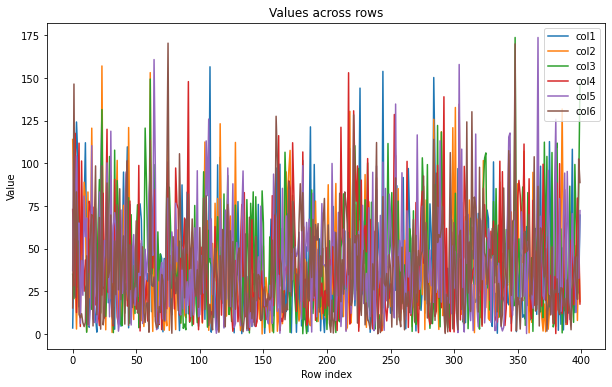

In [4]:
import seaborn as sns
import pandas as pd

# Example
# data = pd.read_csv("data1.csv")

sns.pairplot(output)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(output.values)
plt.xlabel("Row index")
plt.ylabel("Value")
plt.title("Values across rows")
plt.legend(output.columns)
plt.show()


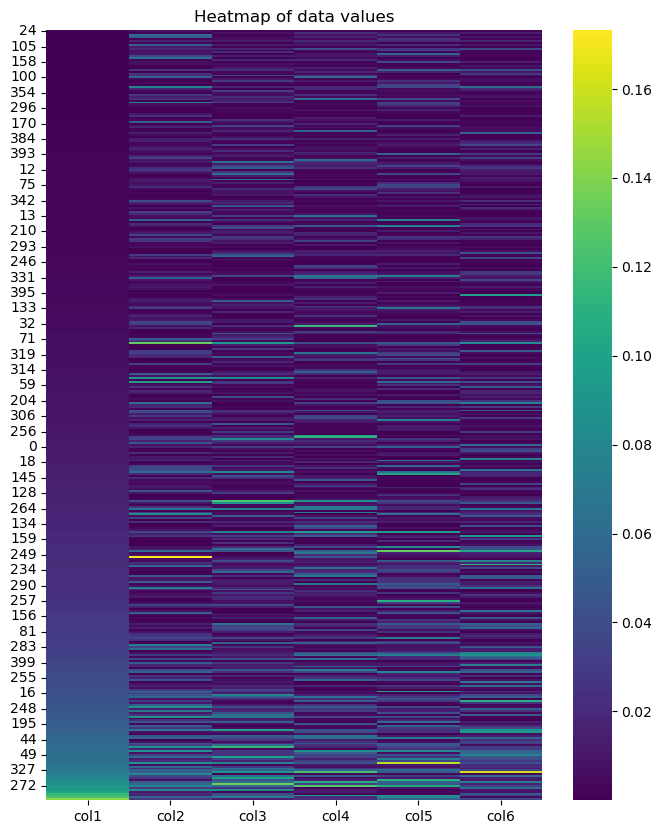

In [5]:
sorted_output = output.sort_values(by=output.columns.tolist())

plt.figure(figsize=(8, 10))

sns.heatmap(sorted_output, cmap="viridis")

plt.title("Heatmap of data values")
plt.show()


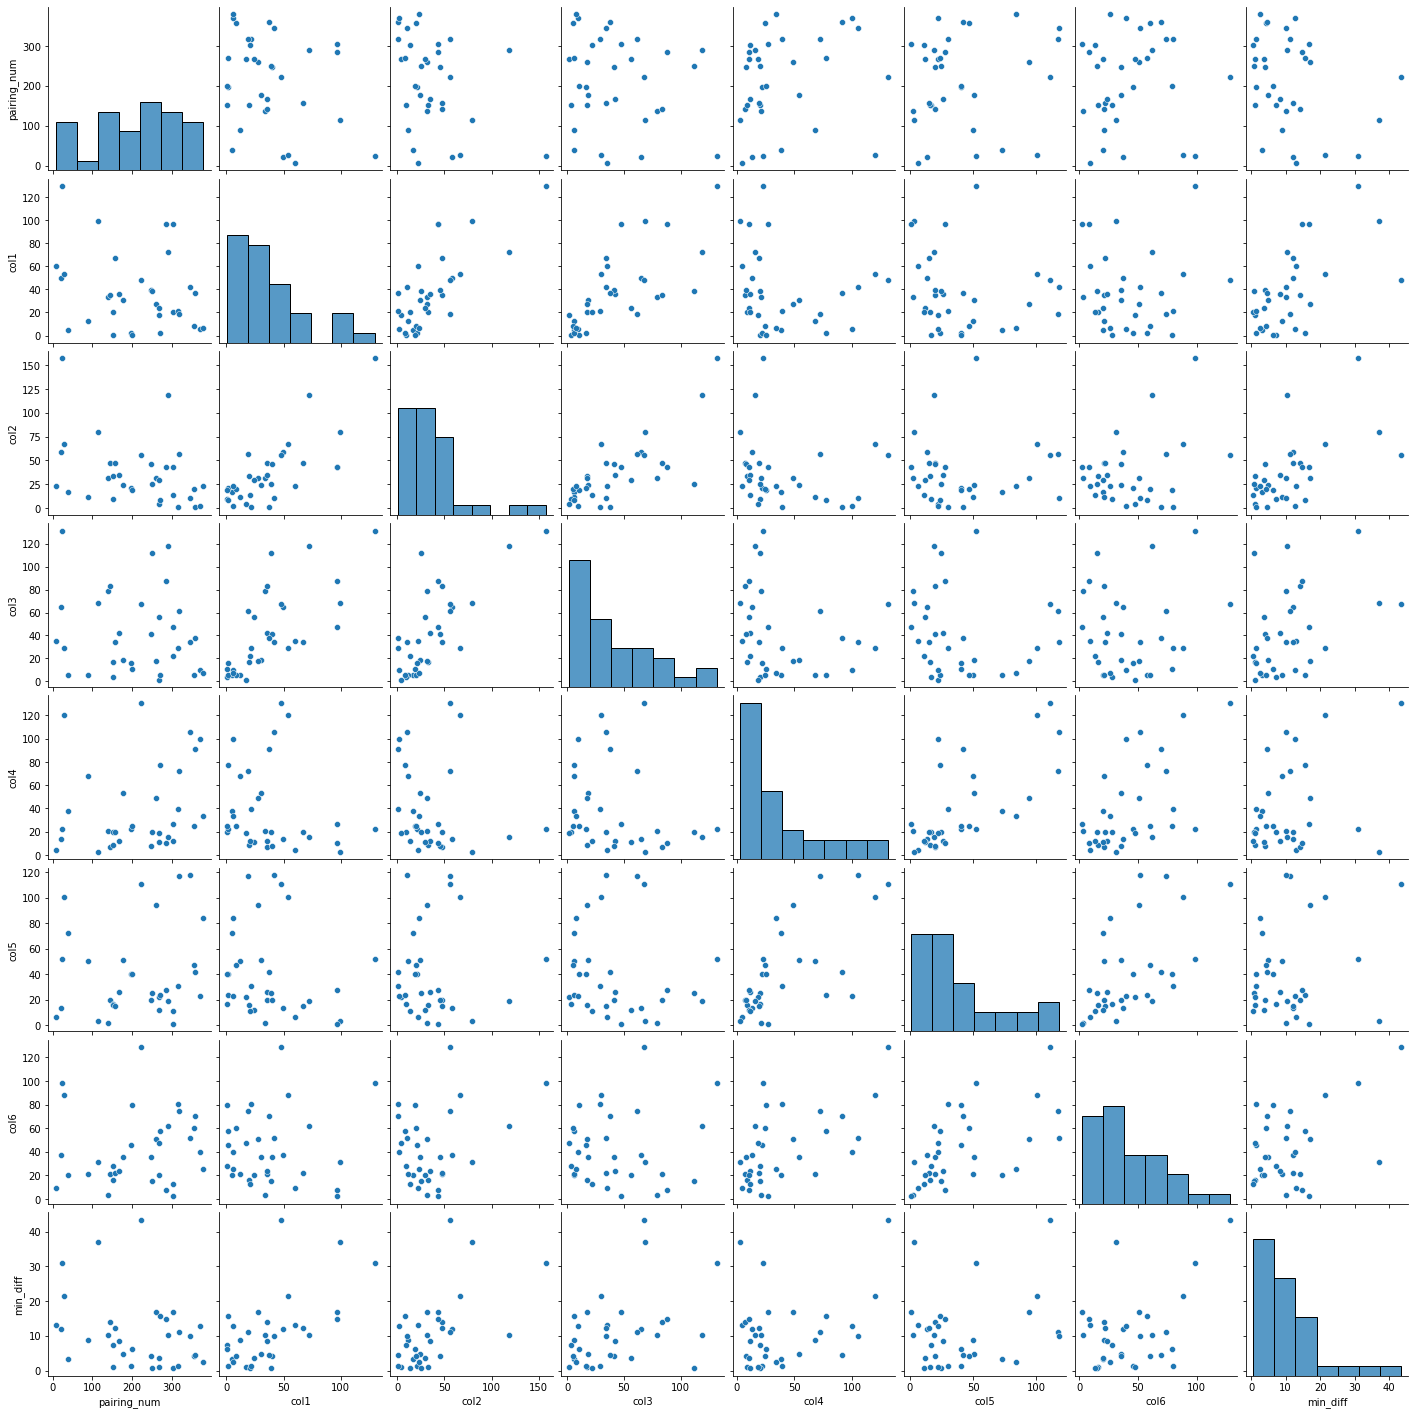

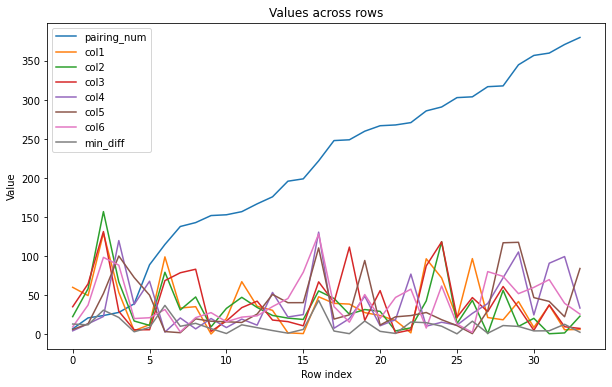

In [5]:
import seaborn as sns
import pandas as pd

# Example
# data = pd.read_csv("data1.csv")

sns.pairplot(filtered_output)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(filtered_output.values)
plt.xlabel("Row index")
plt.ylabel("Value")
plt.title("Values across rows")
plt.legend(filtered_output.columns)
plt.show()


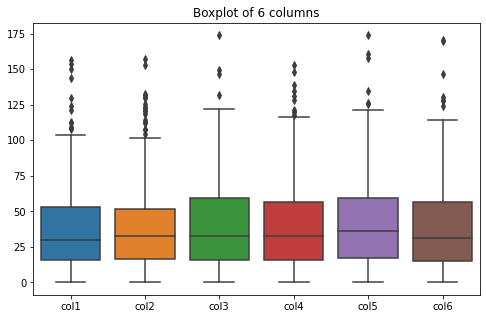

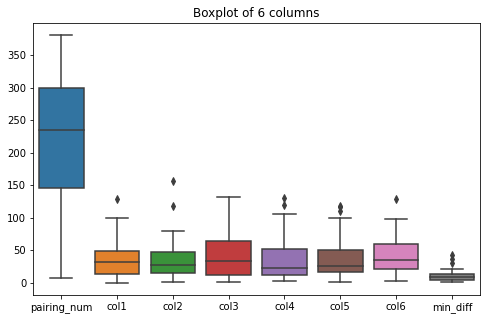

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=output)
plt.title("Boxplot of 6 columns")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=filtered_output)
plt.title("Boxplot of 6 columns")
plt.show()


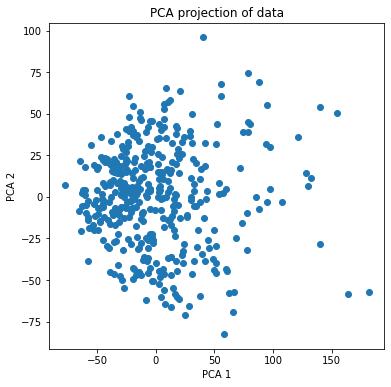

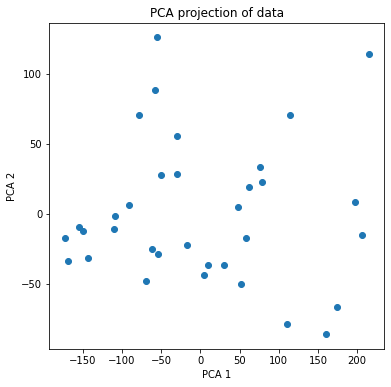

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(output)

plt.figure(figsize=(6,6))
plt.scatter(pca_result[:,0], pca_result[:,1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA projection of data')
plt.show()

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(filtered_output)

plt.figure(figsize=(6,6))
plt.scatter(pca_result[:,0], pca_result[:,1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA projection of data')
plt.show()
